In [1]:
import pandas as pd
import numpy as np

In [2]:
#read the kegg_edges/fusion_kegg_edges_with_experiment500stringdbthreshold_and_coexpression_scores.csv

df = pd.read_csv("kegg_edges/fusion_kegg_edges_with_experiment500stringdbthreshold_and_coexpression_scores.csv")

df.head()


,pathway_id,node1_kegg_id,node1_symbol,node1_type,node1_entry_id,node2_kegg_id,node2_symbol,node2_type,node2_entry_id,relation_type,subtype_1_name,subtype_1_value,subtype_2_name,subtype_2_value,subtype_3_name,subtype_3_value,ExperimentScore,CoexpressionScore
0,hsa03320,undefined,NaN,group,79,hsa:3157 hsa:3158,"HMGCS1, HMGCS...",gene,48,GErel,expression,-->,NaN,NaN,NaN,NaN,0,0
1,hsa03320,undefined,NaN,group,79,hsa:335,"APOA1, AMYLD3, HPALP2, apo(a)",gene,72,GErel,expression,-->,NaN,NaN,NaN,NaN,0,0
2,hsa03320,undefined,NaN,group,79,hsa:336,"APOA2, Apo-AII, ApoA-II, apoAII",gene,57,GErel,expression,-->,NaN,NaN,NaN,NaN,0,0
3,hsa03320,undefined,NaN,group,79,hsa:345,"APOC3, APOCIII, Apo-C3, ApoC-3",gene,68,GErel,expression,-->,NaN,NaN,NaN,NaN,0,0
4,hsa03320,undefined,NaN,group,79,hsa:116519,"APOA5, APOAV, RAP3",gene,75,GErel,expression,-->,NaN,NaN,NaN,NaN,0,0


In [3]:
#sort the df by experiment_score in descending order
df_sorted_experiment = df.sort_values(by="ExperimentScore", ascending=False)
#show the top 20 rows
df_sorted_experiment.head(20)

,pathway_id,node1_kegg_id,node1_symbol,node1_type,node1_entry_id,node2_kegg_id,node2_symbol,node2_type,node2_entry_id,relation_type,subtype_1_name,subtype_1_value,subtype_2_name,subtype_2_value,subtype_3_name,subtype_3_value,ExperimentScore,CoexpressionScore
4567,hsa04660,hsa:3265 hsa:3845 hsa:4893,"HRAS, C-BAS/HAS, C-H-RAS, C-HA-RAS1, CTLO, H-R...",gene,37,hsa:5894,"RAF1, CMD1NN, CRAF, NS5, Raf-1, c-Raf",gene,149,PPrel,activation,-->,NaN,NaN,NaN,NaN,999,0
8187,hsa05162,hsa:23586,"RIGI, DDX58, RIG-I, RIG1, RLR-1, SGMRT2",gene,60,hsa:57506,"MAVS, CARDIF, IPS-1, IPS1, VISA",gene,72,PPrel,activation,-->,NaN,NaN,NaN,NaN,999,42
9541,hsa05213,hsa:1950,"EGF, HOMG4, URG",gene,38,hsa:1956,"EGFR, ERBB, ERBB1, ERRP, HER1, NISBD2, NNCIS, ...",gene,31,PPrel,activation,-->,NaN,NaN,NaN,NaN,999,0
1890,hsa04150,hsa:2475,"MTOR, FRAP, FRAP1, FRAP2, RAFT1, RAPT1, SKS",gene,140,hsa:64223,"MLST8, GBL, GbetaL, LST8, POP3, WAT1",gene,142,PPrel,binding/association,---,NaN,NaN,NaN,NaN,999,49
2561,hsa04350,hsa:4087 hsa:4088,"SMAD2, CHTD8, JV18, JV18-1, LDS6, MADH2, MADR2...",gene,19,hsa:4089,"SMAD4, DPC4, JIP, MADH4, MYHRS",gene,15,PPrel,activation,-->,NaN,NaN,NaN,NaN,999,85
2560,hsa04350,hsa:4087 hsa:4088,"SMAD2, CHTD8, JV18, JV18-1, LDS6, MADH2, MADR2...",gene,22,hsa:4089,"SMAD4, DPC4, JIP, MADH4, MYHRS",gene,16,PPrel,activation,-->,NaN,NaN,NaN,NaN,999,85
1892,hsa04150,hsa:2475,"MTOR, FRAP, FRAP1, FRAP2, RAFT1, RAPT1, SKS",gene,140,hsa:57521,"RPTOR, KOG1, Mip1",gene,143,PPrel,binding/association,---,NaN,NaN,NaN,NaN,999,220
2559,hsa04350,hsa:4087 hsa:4088,"SMAD2, CHTD8, JV18, JV18-1, LDS6, MADH2, MADR2...",gene,43,hsa:4089,"SMAD4, DPC4, JIP, MADH4, MYHRS",gene,41,PPrel,activation,-->,NaN,NaN,NaN,NaN,999,85
1894,hsa04150,hsa:2475,"MTOR, FRAP, FRAP1, FRAP2, RAFT1, RAPT1, SKS",gene,153,hsa:64223,"MLST8, GBL, GbetaL, LST8, POP3, WAT1",gene,156,PPrel,binding/association,---,NaN,NaN,NaN,NaN,999,49
9734,hsa05218,hsa:1950 hsa:2246 hsa:2247 hsa:2248 hsa:2249 h...,"EGF, HOMG4, URG...",gene,15,hsa:1956 hsa:2260 hsa:3480 hsa:4233 hsa:5156 h...,"EGFR, ERBB, ERBB1, ERRP, HER1, NISBD2, NNCIS, ...",gene,14,PPrel,activation,-->,NaN,NaN,NaN,NaN,999,0


Range of ExperimentScore: 0 - 999


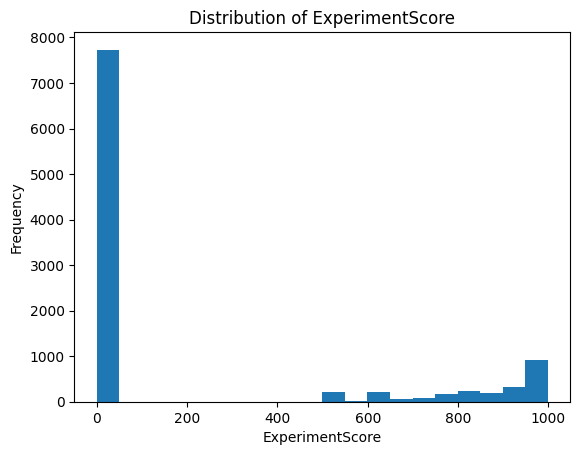

In [4]:
#show the range of ExperimentScore column
print("Range of ExperimentScore:", df["ExperimentScore"].min(), "-", df["ExperimentScore"].max())
#show the distribution of ExperimentScore column
import matplotlib.pyplot as plt
plt.hist(df["ExperimentScore"], bins=20)
plt.xlabel("ExperimentScore")
plt.ylabel("Frequency")
plt.title("Distribution of ExperimentScore")
plt.show()

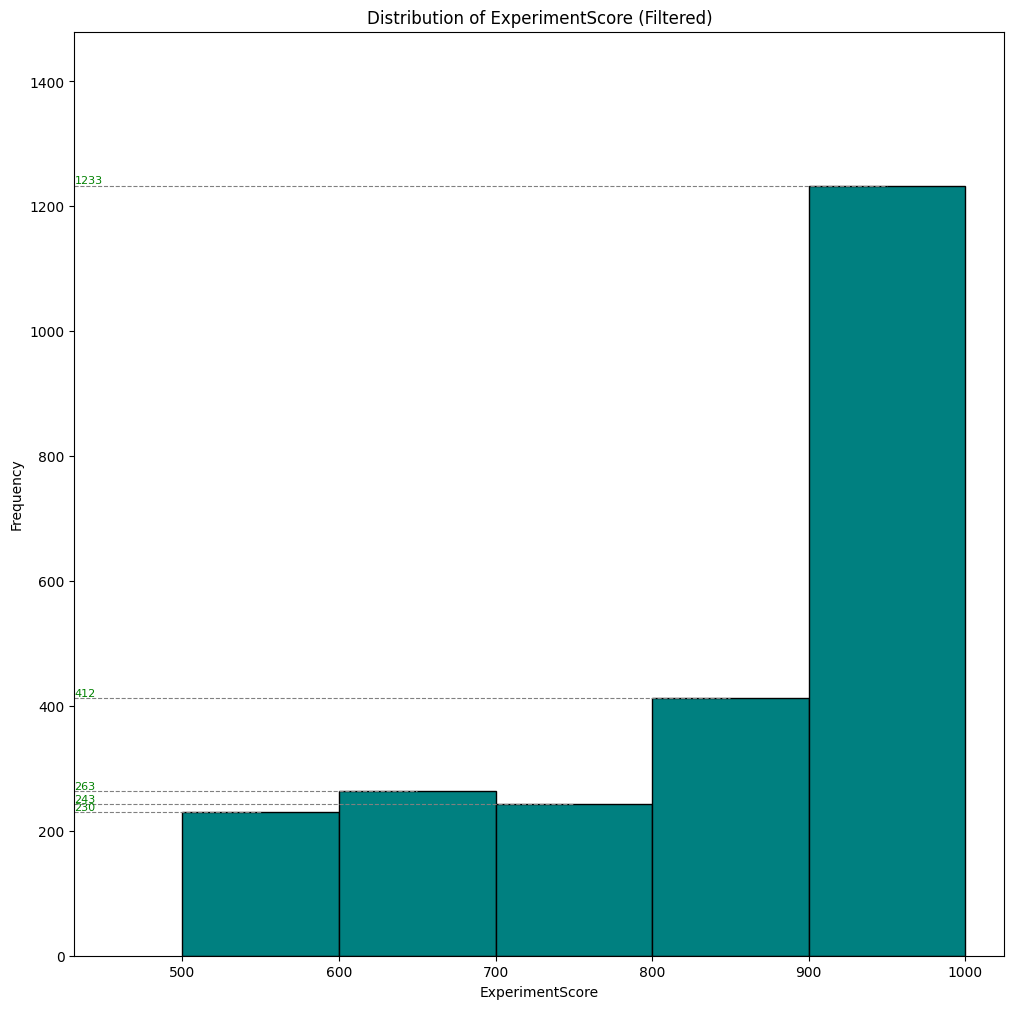

In [5]:
# #filter experimentscore>500 and plot distribution showing the number of rows in each bin
df_filtered = df[df["ExperimentScore"] >= 500]

fig, ax = plt.subplots(figsize=(12, 12))
bin_edges = [500, 600, 700, 800, 900, 1000]
counts, bin_edges, patches = ax.hist(
    df_filtered["ExperimentScore"],
    bins=bin_edges,
    edgecolor="black",
    linewidth=1,
    color="teal"
)
ax.set_xlabel("ExperimentScore")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of ExperimentScore (Filtered)")
ax.set_xticks(bin_edges)

# Add some left margin so labels at the y-axis are visible
x_min, x_max = ax.get_xlim()
x_span = x_max - x_min
ax.set_xlim(x_min - 0.08 * x_span, x_max)

# Add vertical headroom so y-axis labels are easier to read
max_count = counts.max()
ax.set_ylim(0, max_count * 1.2)

# Connect each bar top to the y-axis with a dashed horizontal line
# and place the bar count at the y-axis endpoint
x_axis_point = ax.get_xlim()[0]
for count, patch in zip(counts, patches):
    if count <= 0:
        continue
    x_center = patch.get_x() + patch.get_width() / 2
    y = count
    ax.plot([x_axis_point, x_center], [y, y], linestyle="dashed", color="gray", linewidth=0.8)
    #make the text a bit to the right of the y-axis so it doesn't overlap with the axis line
    ax.text(x_axis_point, y, f"{int(count)}", ha="left", va="bottom", fontsize=8, color="green")
plt.show()

In [6]:
print("Total number of rows:", len(df))
print("Total number of rows with ExperimentScore >= 500:", len(df_filtered))

Total number of rows: 10112
Total number of rows with ExperimentScore >= 500: 2381


In [7]:
#number of rows with experiment score >=900, 800-900, 700-800, 600-700, 500-600
print("Number of rows with ExperimentScore >= 900:", len(df[df["ExperimentScore"] >= 900]))
print("Number of rows with ExperimentScore between 800 and 900:", len(df[(df["ExperimentScore"] >= 800) & (df["ExperimentScore"] < 900)]))
print("Number of rows with ExperimentScore between 700 and 800:", len(df[(df["ExperimentScore"] >= 700) & (df["ExperimentScore"] < 800)]))
print("Number of rows with ExperimentScore between 600 and 700:", len(df[(df["ExperimentScore"] >= 600) & (df["ExperimentScore"] < 700)]))
print("Number of rows with ExperimentScore between 500 and 600:", len(df[(df["ExperimentScore"] >= 500) & (df["ExperimentScore"] < 600)]))


Number of rows with ExperimentScore >= 900: 1233
Number of rows with ExperimentScore between 800 and 900: 412
Number of rows with ExperimentScore between 700 and 800: 243
Number of rows with ExperimentScore between 600 and 700: 263
Number of rows with ExperimentScore between 500 and 600: 230


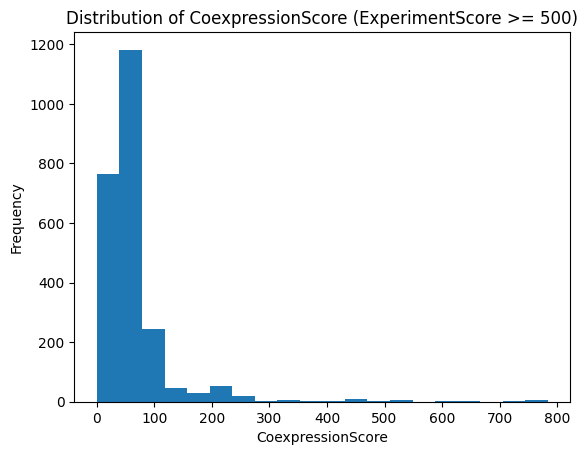

In [8]:
#now for all the rows with experiment score >=500, show the distribution of coexpression score
df_filtered_coexpression = df[df["ExperimentScore"] >= 500]
plt.hist(df_filtered_coexpression["CoexpressionScore"], bins=20)
plt.xlabel("CoexpressionScore")
plt.ylabel("Frequency")
plt.title("Distribution of CoexpressionScore (ExperimentScore >= 500)")
plt.show()


In [9]:
#see how many different values are there in the subtype_1_name and subtype_2_name columns
print("Unique values in subtype_1_name:", df["subtype_1_name"].unique())
print("Unique values in subtype_2_name:", df["subtype_2_name"].unique())


Unique values in subtype_1_name: <StringArray>
[         'expression',          'activation',     'phosphorylation',
 'binding/association',      'ubiquitination',          'inhibition',
   'dephosphorylation',     'indirect effect',            'compound',
                   nan,        'dissociation',          'repression',
        'state change', 'missing interaction']
Length: 14, dtype: str
Unique values in subtype_2_name: <StringArray>
[                  nan,     'phosphorylation',   'dephosphorylation',
     'indirect effect', 'binding/association',          'activation',
      'ubiquitination',         'methylation',          'inhibition',
        'dissociation',            'indirect',          'repression',
 'missing interaction',          'expression']
Length: 14, dtype: str


In [10]:
#how many rows have coexpressionscore greater than 600
print("Number of rows with CoexpressionScore > 600:", len(df[df["CoexpressionScore"] > 600]))

Number of rows with CoexpressionScore > 600: 13


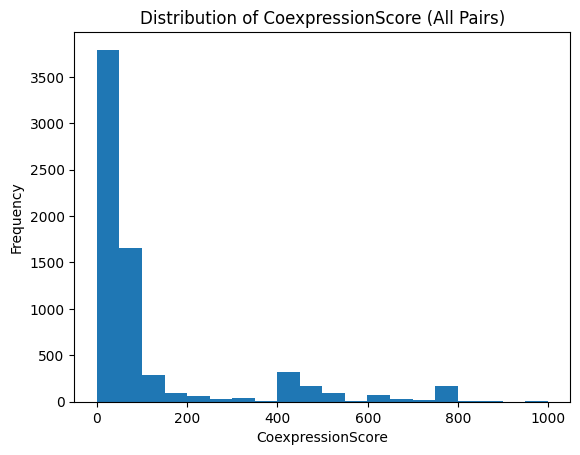

In [11]:
#coexpression_csv/hsa_stringdb_coexpression_links.csv contains pairs of all nodes present in our kegg subset with their coexpression scores,read the csv and make a distribution of all coexpression pairs
coexpression_df = pd.read_csv("coexpression_csv/hsa_stringdb_coexpression_links.csv")
plt.hist(coexpression_df["coexpression_score"], bins=20)
plt.xlabel("CoexpressionScore")
plt.ylabel("Frequency")
plt.title("Distribution of CoexpressionScore (All Pairs)")
plt.show()

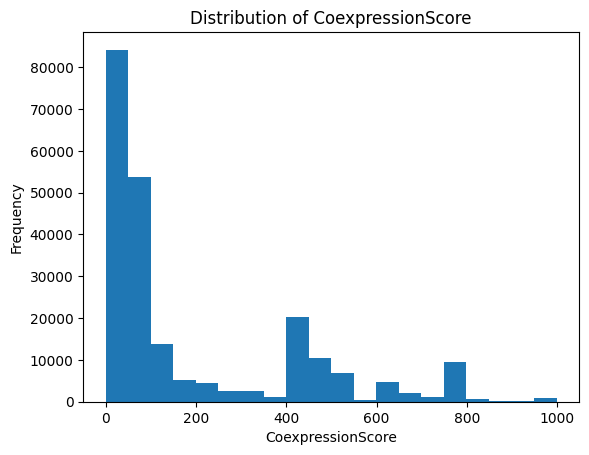

In [12]:
#coexpression_csv/StringDB.9606.protein.links.ModifiedWithEnsemblDerivedGeneNames_experimentthreshold400_coexpressionthreshold400.csv contains a refined subset of string db. show the coexpression score distribution for this subset
refined_coexpression_df = pd.read_csv("coexpression_csv/StringDB.9606.protein.links.ModifiedWithEnsemblDerivedGeneNames_experimentthreshold400_coexpressionthreshold400.csv")
plt.hist(refined_coexpression_df["coexpression"], bins=20)
plt.xlabel("CoexpressionScore")
plt.ylabel("Frequency")
plt.title("Distribution of CoexpressionScore")
plt.show() 

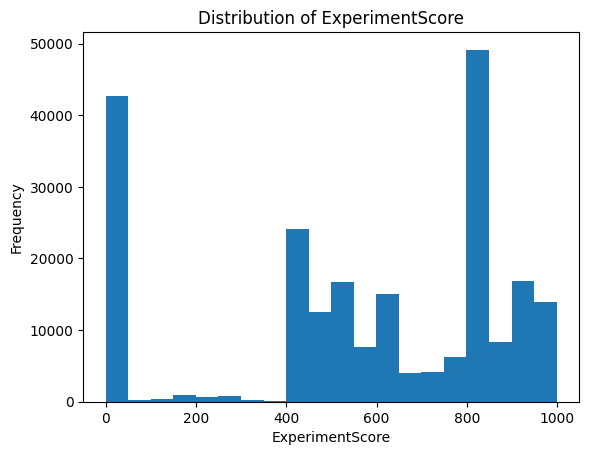

In [13]:
#now do the same for experiment channel
plt.hist(refined_coexpression_df["experiments"], bins=20)
plt.xlabel("ExperimentScore")
plt.ylabel("Frequency")
plt.title("Distribution of ExperimentScore")
plt.show()

In [14]:
#show the range of coexpression scores and experiment scores in the refined subset
print("Range of CoexpressionScore in refined subset:", refined_coexpression_df["coexpression"].min(), "-", refined_coexpression_df["coexpression"].max())
print("Range of ExperimentScore in experiment channel of refined subset:", refined_coexpression_df["experiments"].min(), "-", refined_coexpression_df["experiments"].max()) 


Range of CoexpressionScore in refined subset: 0 - 999
Range of ExperimentScore in experiment channel of refined subset: 0 - 999


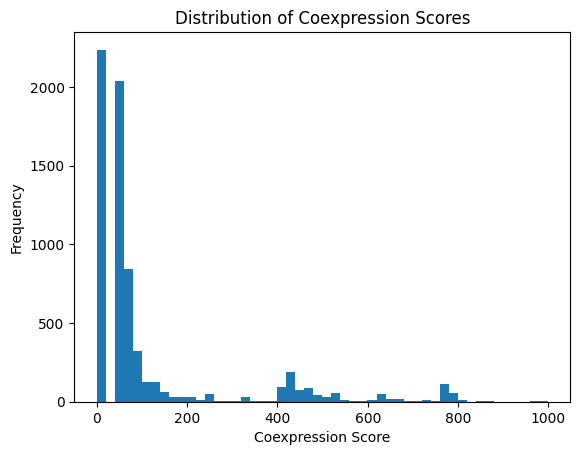

In [15]:
#coexpression_csv/hsa_stringdb_coexpression_links.csv, draw the distribution of coexpression scores for pairs in this csv

df = pd.read_csv('coexpression_csv/hsa_stringdb_coexpression_links.csv')
plt.hist(df['coexpression_score'], bins=50)
plt.xlabel('Coexpression Score')
plt.ylabel('Frequency')
plt.title('Distribution of Coexpression Scores')
plt.show()

In [16]:
#show the number of rows in each range 400-500, 500-600, 600-700, 700-800, 800-900, 900-1000
print("Number of rows with CoexpressionScore between 400 and 500:", len(df[(df["coexpression_score"] >= 400) & (df["coexpression_score"] < 500)]))
print("Number of rows with CoexpressionScore between 500 and 600:", len(df[(df["coexpression_score"] >= 500) & (df["coexpression_score"] < 600)]))
print("Number of rows with CoexpressionScore between 600 and 700:", len(df[(df["coexpression_score"] >= 600) & (df["coexpression_score"] < 700)]))
print("Number of rows with CoexpressionScore between 700 and 800:", len(df[(df["coexpression_score"] >= 700) & (df["coexpression_score"] < 800)]))
print("Number of rows with CoexpressionScore between 800 and 900:", len(df[(df["coexpression_score"] >= 800) & (df["coexpression_score"] < 900)]))
print("Number of rows with CoexpressionScore between 900 and 999:", len(df[(df["coexpression_score"] >= 900) & (df["coexpression_score"] <= 1000)]))   

Number of rows with CoexpressionScore between 400 and 500: 497
Number of rows with CoexpressionScore between 500 and 600: 100
Number of rows with CoexpressionScore between 600 and 700: 100
Number of rows with CoexpressionScore between 700 and 800: 184
Number of rows with CoexpressionScore between 800 and 900: 14
Number of rows with CoexpressionScore between 900 and 999: 8


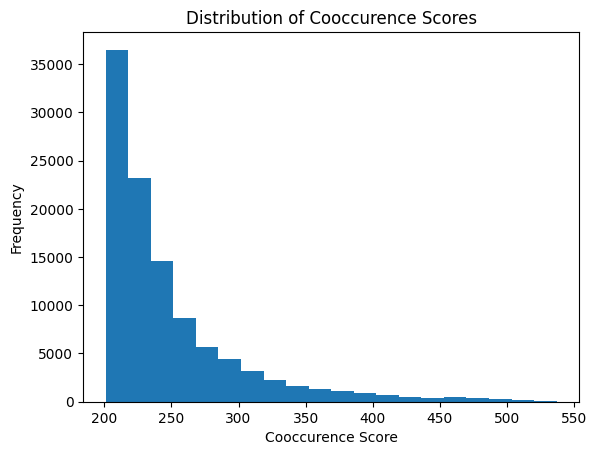

In [27]:
df = pd.read_csv('cooccurence_csv/string_cooccurence200_pairs.csv')
plt.hist(df['cooccurence'], bins=20)
plt.xlabel('Cooccurence Score')
plt.ylabel('Frequency')
plt.title('Distribution of Cooccurence Scores')
plt.show()

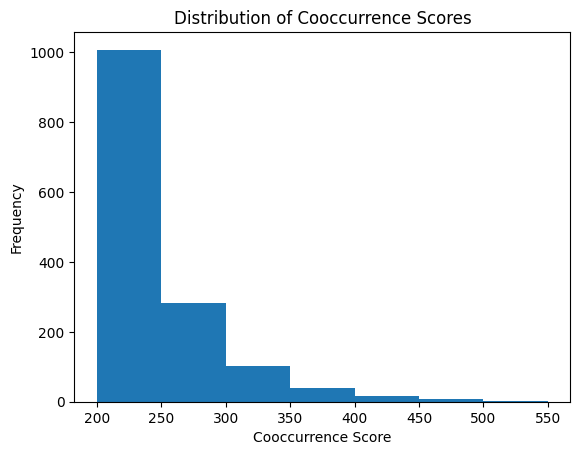

In [28]:
df = pd.read_csv('cooccurence_csv/hsa_nodes_string_cooccurence_matches.csv')
#plot histogram with each bar in the range 200-250, 250-300, 300-350, 350-400, 400-450, 450-500, 500-550
plt.hist(df['cooccurence'], bins=[200, 250, 300, 350, 400, 450, 500, 550])
plt.xlabel('Cooccurrence Score')
plt.ylabel('Frequency')
plt.title('Distribution of Cooccurrence Scores')
plt.show()

In [29]:
#print the counts of cooccurrence scores in the ranges 200-250, 250-300, 300-350, 350-400, 400-450, 450-500, 500-550 and print the counts in a nice format
print("Number of rows with Cooccurrence Score between 200 and 250:", len(df[(df["cooccurence"] >= 200) & (df["cooccurence"] < 250)]))
print("Number of rows with Cooccurrence Score between 250 and 300:", len(df[(df["cooccurence"] >= 250) & (df["cooccurence"] < 300)]))
print("Number of rows with Cooccurrence Score between 300 and 350:", len(df[(df["cooccurence"] >= 300) & (df["cooccurence"] < 350)]))
print("Number of rows with Cooccurrence Score between 350 and 400:", len(df[(df["cooccurence"] >= 350) & (df["cooccurence"] < 400)]))
print("Number of rows with Cooccurrence Score between 400 and 450:", len(df[(df["cooccurence"] >= 400) & (df["cooccurence"] < 450)]))
print("Number of rows with Cooccurrence Score between 450 and 500:", len(df[(df["cooccurence"] >= 450) & (df["cooccurence"] < 500)]))
print("Number of rows with Cooccurrence Score between 500 and 550:", len(df[(df["cooccurence"] >= 500) & (df["cooccurence"] < 550)]))
#print total number of rows
print("Total number of rows:", len(df))

Number of rows with Cooccurrence Score between 200 and 250: 1007
Number of rows with Cooccurrence Score between 250 and 300: 281
Number of rows with Cooccurrence Score between 300 and 350: 101
Number of rows with Cooccurrence Score between 350 and 400: 38
Number of rows with Cooccurrence Score between 400 and 450: 17
Number of rows with Cooccurrence Score between 450 and 500: 9
Number of rows with Cooccurrence Score between 500 and 550: 1
Total number of rows: 1454
